In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from numpy.linalg import cond

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

In [43]:
# ── 경로 수정 필요 ─────────────────────────────────
SENT_PATH = Path("../data/Sentiment_Final/sentiment_avg_7d_final.csv")
BASE_PATH = Path("../data/Finance_Final/dataset4_derived_full_with_dummies.csv")  # 기존 유가 모델 변수 CSV
# ──────────────────────────────────────────────────

sent_df = pd.read_csv(SENT_PATH, parse_dates=["date"])
base_df = pd.read_csv(BASE_PATH, parse_dates=["date"])

# sent_ 로 시작하는 감성점수 변수만 사용 (news_*, nonews_* 제외)
sent_keep = ["date"] + [c for c in sent_df.columns if c.startswith("sent_")]
sent_df = sent_df[sent_keep]

print(f"sent_df: {sent_df.shape}, {sent_df['date'].min().date()} ~ {sent_df['date'].max().date()}")
print(f"base_df: {base_df.shape}, {base_df['date'].min().date()} ~ {base_df['date'].max().date()}")

df = base_df.merge(sent_df, on="date", how="inner").sort_values("date").reset_index(drop=True)
print(f"merged : {df.shape}, {df['date'].min().date()} ~ {df['date'].max().date()}")

sent_df: (6810, 5), 2007-08-09 ~ 2026-03-31
base_df: (4799, 44), 2007-02-01 ~ 2026-03-16
merged : (4668, 48), 2007-08-09 ~ 2026-03-16


In [44]:
# ── 변수 그룹 정의 ─────────────────────────────────
CATEGORIES = ["supply", "demand", "geopolitical", "financial"]

sent_cols     = [f"sent_{c}_7d" for c in CATEGORIES]
sentiment_all = sent_cols  # 감성점수 변수만 사용 (news_*, nonews_* 제외)

# 기존 유가 모델 변수 — 일부 변수 제외
DROP_BASE = ["cond_termspread_inv", "MA_20", "cond_vix_gt_30"]
base_cols = [c for c in base_df.columns if c != "date" and c not in DROP_BASE]

# 타겟 변수
TARGET = "oil_diff_target"

print(f"sentiment ({len(sentiment_all)}): {sentiment_all}")
print(f"base ({len(base_cols)}): {base_cols}")
print(f"제외된 변수: {DROP_BASE}")

sentiment (4): ['sent_supply_7d', 'sent_demand_7d', 'sent_geopolitical_7d', 'sent_financial_7d']
base (40): ['oil_diff_target', 'OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'FedFundsRate', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_volatility_5', 'oil_volatility_20', 'MA_5', 'MA_ratio', 'MA_5_gt_MA_20', 'oil_momentum_5', 'oil_momentum_20', 'TermSpread_inversion', 'vix_high', 'is_monday', 'is_friday', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'covid_2020_regime', 'war_2022_shock', 'war_2022_regime', 'gfc_2008_window', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_inventory_draw', 'cond_opec_cut']
제외된 변수: ['cond_termspread_inv', 'MA_20', 'cond_vix_gt_30']


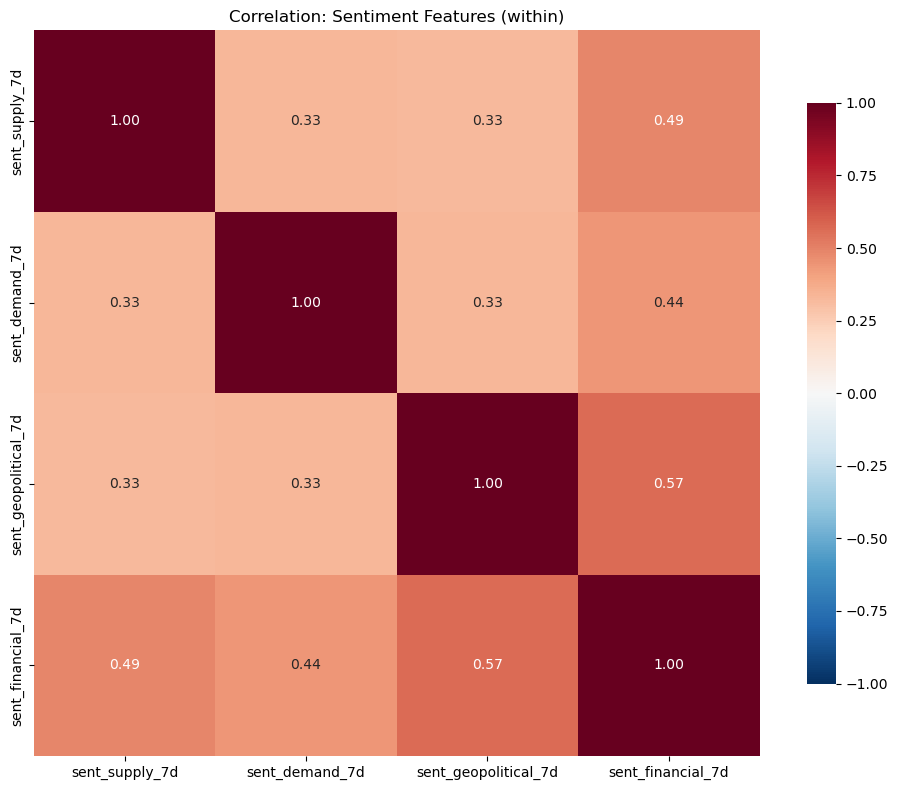

In [45]:
# 2-1. sentiment 변수끼리
corr_sent = df[sentiment_all].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_sent, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation: Sentiment Features (within)")
plt.tight_layout(); plt.show()

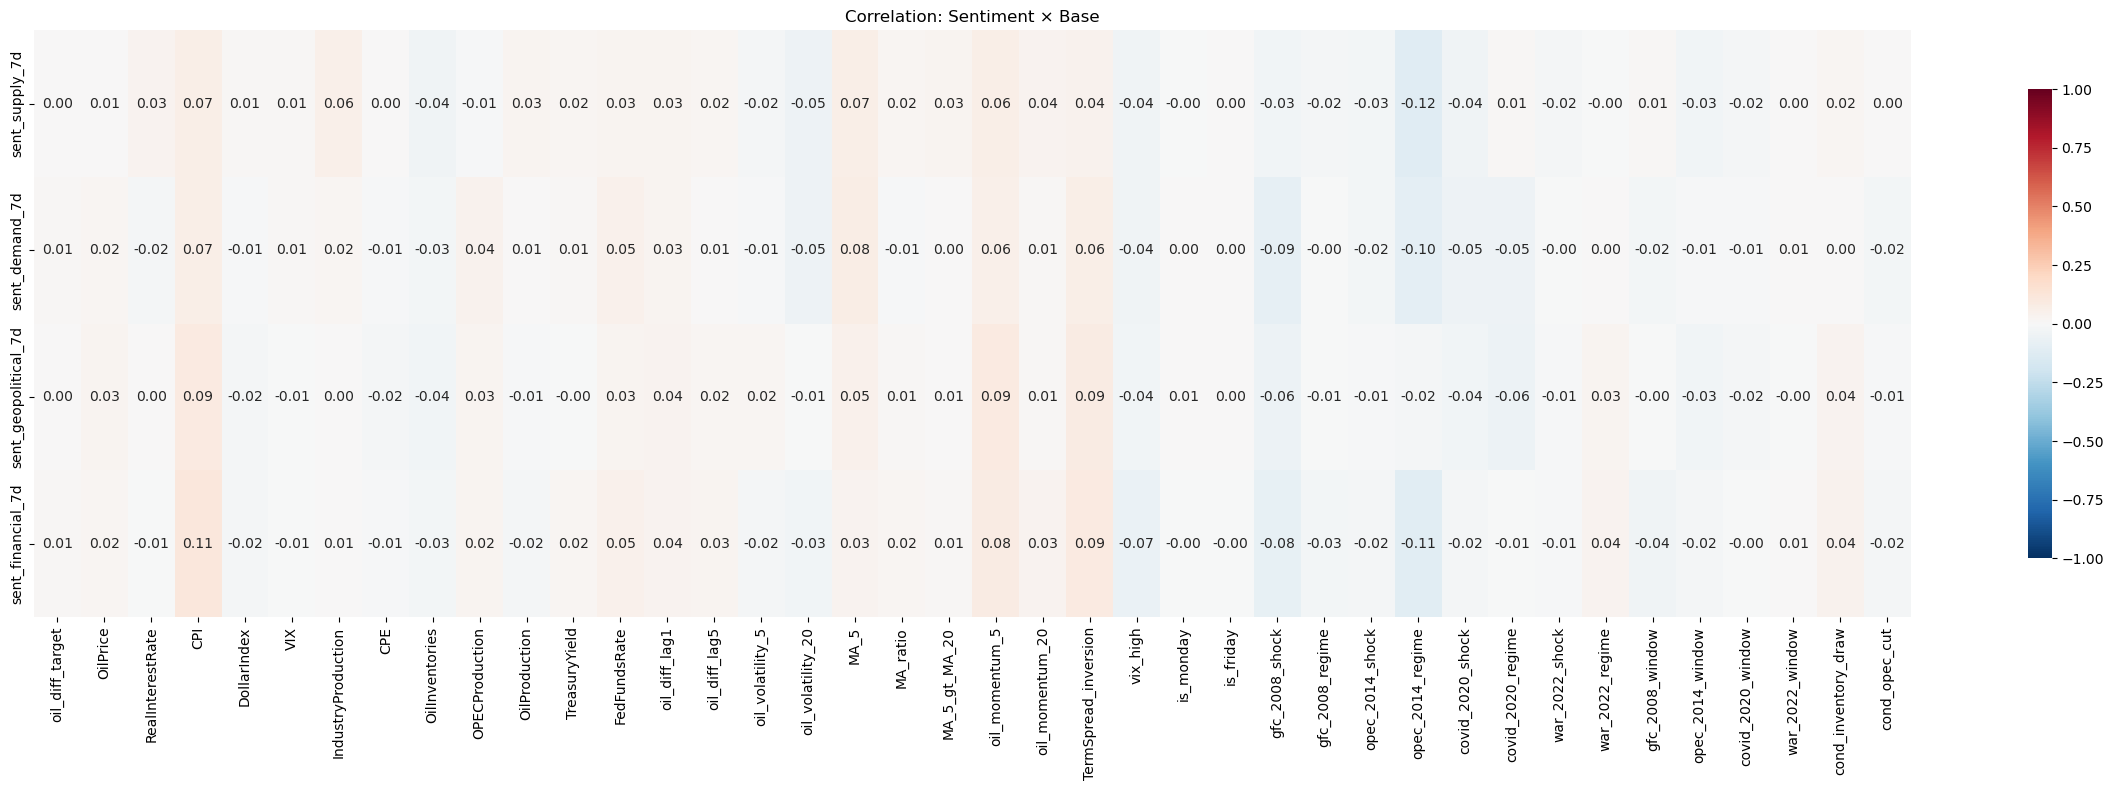

In [46]:
# 2-2. sentiment × base
corr_cross = df[sentiment_all + base_cols].corr().loc[sentiment_all, base_cols]

fig, ax = plt.subplots(figsize=(max(8, len(base_cols)*0.6), 8))
sns.heatmap(corr_cross, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation: Sentiment × Base")
plt.tight_layout(); plt.show()

In [47]:
# 2-3. |r| > 0.7 강한 상관 쌍 추출
THRESHOLD = 0.7

all_cols  = sentiment_all + base_cols
corr_full = df[all_cols].corr().abs()

mask = np.triu(np.ones_like(corr_full, dtype=bool), k=1)
corr_pairs = (
    corr_full.where(mask).stack().reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "abs_corr"})
)
corr_pairs = corr_pairs[corr_pairs["abs_corr"] > THRESHOLD].sort_values("abs_corr", ascending=False)
display(corr_pairs.head(30))

,var1,var2,abs_corr
385,IndustryProduction,CPE,0.771285
717,MA_ratio,oil_momentum_20,0.715128
479,OilInventories,cond_inventory_draw,0.714830


In [48]:
def compute_vif(X: pd.DataFrame) -> pd.Series:
    X_clean = X.dropna()
    if X_clean.shape[0] < X_clean.shape[1] + 5:
        raise ValueError(f"표본 부족: rows={X_clean.shape[0]}, cols={X_clean.shape[1]}")
    Xc = add_constant(X_clean, has_constant="add")
    vifs = pd.Series(
        [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
        index=Xc.columns
    )
    return vifs.drop("const").sort_values(ascending=False)

vif_base = compute_vif(df[base_cols])
vif_full = compute_vif(df[base_cols + sentiment_all])

vif_compare = pd.concat(
    [vif_base.rename("VIF_base"), vif_full.rename("VIF_full")],
    axis=1
)
vif_compare["delta"] = vif_compare["VIF_full"] - vif_compare["VIF_base"]
vif_compare = vif_compare.sort_values("VIF_full", ascending=False).round(2)
display(vif_compare)

# 판정: VIF > 10 심각 / > 5 주의
print("\n=== VIF > 10 ===")
display(vif_compare[vif_compare["VIF_full"] > 10])
print("\n=== VIF 5~10 ===")
display(vif_compare[(vif_compare["VIF_full"] > 5) & (vif_compare["VIF_full"] <= 10)])

,VIF_base,VIF_full,delta
covid_2020_shock,5.38,5.39,0.00
CPE,5.04,5.07,0.03
MA_ratio,5.04,5.06,0.02
IndustryProduction,4.16,4.18,0.03
OPECProduction,3.92,3.94,0.02
oil_momentum_20,3.89,3.91,0.02
oil_volatility_20,3.82,3.83,0.01
covid_2020_window,2.82,2.82,0.00
oil_volatility_5,2.65,2.66,0.01
gfc_2008_shock,2.61,2.63,0.02



=== VIF > 10 ===


,VIF_base,VIF_full,delta



=== VIF 5~10 ===


,VIF_base,VIF_full,delta
covid_2020_shock,5.38,5.39,0.00
CPE,5.04,5.07,0.03
MA_ratio,5.04,5.06,0.02


In [49]:
def condition_number(X: pd.DataFrame) -> float:
    Xs = (X - X.mean()) / X.std()  # 표준화 후 계산
    Xs = Xs.dropna()
    return cond(Xs.values)

cn_base = condition_number(df[base_cols])
cn_full = condition_number(df[base_cols + sentiment_all])

print(f"Condition Number (Base)        : {cn_base:>10.1f}")
print(f"Condition Number (Base+Sent)   : {cn_full:>10.1f}")
print(f"증가폭                          : {cn_full - cn_base:>10.1f}")

# 판정: CN > 30 다중공선성 우려 / > 100 심각

Condition Number (Base)        :        7.2
Condition Number (Base+Sent)   :        7.2
증가폭                          :        0.0


In [50]:
# 각 sentiment 변수가 base 변수로 얼마나 설명되는가
# R² 높으면 → 해당 sentiment 변수는 base 변수들의 선형결합과 거의 같음 (중복 정보)

import statsmodels.api as sm

partial_r2 = []
for sv in sentiment_all:
    y = df[sv]
    X = df[base_cols + [c for c in sentiment_all if c != sv]]
    valid = y.notna() & X.notna().all(axis=1)
    if valid.sum() < 100:
        continue
    model = sm.OLS(y[valid], add_constant(X[valid])).fit()
    partial_r2.append({"sentiment_var": sv, "R²_by_others": model.rsquared, "VIF_equiv": 1/(1-model.rsquared)})

partial_df = pd.DataFrame(partial_r2).sort_values("R²_by_others", ascending=False)
display(partial_df.round(3))

# R² > 0.9 → 다른 변수로 거의 완전히 설명됨 (중복)
# R² > 0.8 → 정보 중복 상당

,sentiment_var,R²_by_others,VIF_equiv
3,sent_financial_7d,0.479,1.919
2,sent_geopolitical_7d,0.353,1.545
0,sent_supply_7d,0.281,1.391
1,sent_demand_7d,0.240,1.316


In [51]:
def diagnose(row):
    vif = row["VIF_full"]
    if vif > 10: return "🔴 심각 (제거/변환 권장)"
    if vif > 5:  return "🟡 주의 (검토)"
    return "🟢 양호"

vif_compare["판정"] = vif_compare.apply(diagnose, axis=1)
display(vif_compare)

print("\n[종합 권고]")
print(f"- Condition Number: {cn_base:.0f} → {cn_full:.0f} ({'악화' if cn_full > cn_base*1.5 else '유지'})")
print(f"- VIF > 10 변수 수: {(vif_compare['VIF_full'] > 10).sum()}")
print(f"- 강한 상관(|r|>0.7) 쌍: {len(corr_pairs)}")

,VIF_base,VIF_full,delta,판정
covid_2020_shock,5.38,5.39,0.00,🟡 주의 (검토)
CPE,5.04,5.07,0.03,🟡 주의 (검토)
MA_ratio,5.04,5.06,0.02,🟡 주의 (검토)
IndustryProduction,4.16,4.18,0.03,🟢 양호
OPECProduction,3.92,3.94,0.02,🟢 양호
oil_momentum_20,3.89,3.91,0.02,🟢 양호
oil_volatility_20,3.82,3.83,0.01,🟢 양호
covid_2020_window,2.82,2.82,0.00,🟢 양호
oil_volatility_5,2.65,2.66,0.01,🟢 양호
gfc_2008_shock,2.61,2.63,0.02,🟢 양호



[종합 권고]
- Condition Number: 7 → 7 (유지)
- VIF > 10 변수 수: 0
- 강한 상관(|r|>0.7) 쌍: 3
